# DCT1401 - Inteligência Artificial (UFRN)
## Percepções e Análise para o Problema de Regressão
**Aluno:** Wallison Valdemiro Silvino Dias  
**Matrícula:** 20250023771  
**Target:** `AQI` (Air Quality Index)  
**Dataset:** Greek Urban Air Quality & Health Impact Dataset (2020-2024)

---
### Objetivos Desta Etapa
1. Justificação técnica aprofundada da seleção do `AQI` como variável alvo para regressão.
2. Análise da relação entre features preditoras independentes e o target.
3. Quantificação de poder preditivo e importância de atributos com modelo de baseline supervisionado.
4. Identificação de desafios metodológicos (multicolinearidade, não-linearidades, assimetria).
5. Formulação de recomendações de algoritmos e estratégias para modelagem.

In [1]:
import sys
from pathlib import Path

root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from src import data_loader, eda, visualization

visualization.set_plot_style()
print("Módulos carregados com sucesso.")

Módulos carregados com sucesso.


### 1. Identificação e Justificativa da Variável Alvo (`AQI`)
- **Natureza Contínua:** O `AQI` varia continuamente de $12.10$ a $729.10$, com desvio padrão de $48.58$ e média de $93.42$, apresentando riqueza de variabilidade sem colapso de valores discretos.
- **Relevância no Domínio:** O Índice de Qualidade do Ar é a medida oficial adotada pela Agência Europeia do Ambiente (EEA) e pela OMS para orientar restrições sanitárias e políticas de mobilidade urbana.
- **Formulação Preditiva Realista:** Prever o AQI a partir de variáveis climáticas, tráfego, eventos sazonais e geografia permite antecipar a qualidade do ar sem necessidade de estações químicas completas instaladas em cada esquina.

In [2]:
# Carregamento dos dados de regressão
reg_df = data_loader.load_regression_data()
print(f"Dimensões do dataset de regressão: {reg_df.shape}")

# Correlação das features com o target AQI
target_corr = reg_df.corr()["AQI"].sort_values(ascending=False)
display(pd.DataFrame({"Correlação de Pearson com AQI": target_corr}))

Dimensões do dataset de regressão: (453096, 30)


,Correlação de Pearson com AQI
AQI,1.000000
Traffic_Density_Index,0.763416
population,0.429462
industrial_index,0.375189
city_Athens,0.348092
hour,0.308819
city_Thessaloniki,0.242174
Wildfire_Smoke_Event,0.195365
UV_Index,0.183782
Saharan_Dust_Event,0.168610


### 2. Análise de Relações Não-Lineares e Preditivas
Avaliamos o comportamento do target em relação a variáveis com dinâmica não-linear, como velocidade do vento e temperatura.

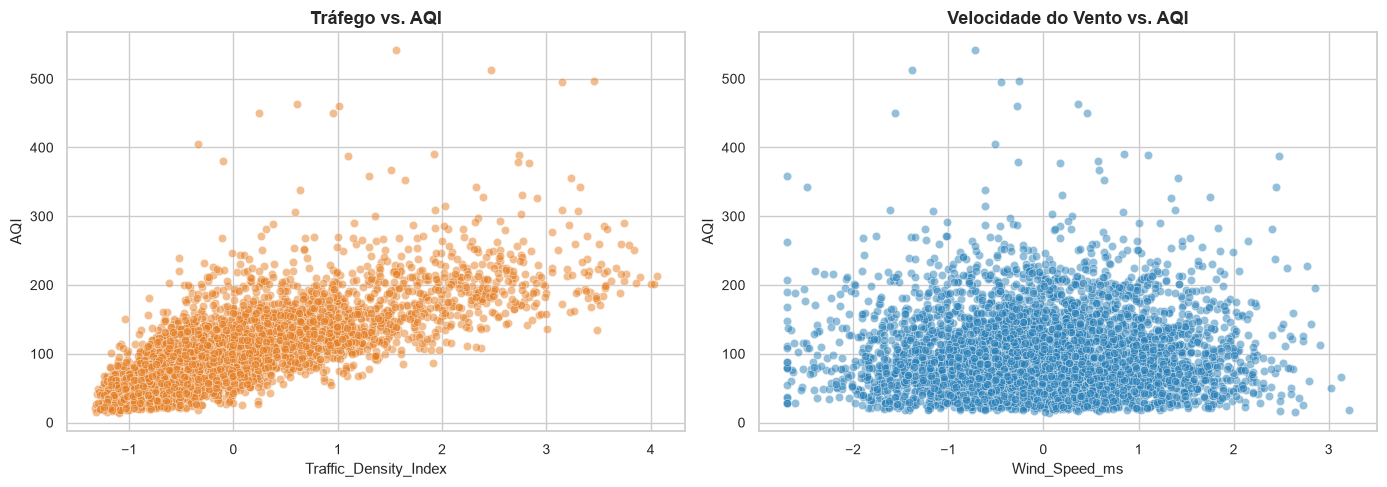

In [3]:
# Gráfico de dispersão com amostra estratificada para visualização nítida
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sample_df = reg_df.sample(5000, random_state=42)

sns.scatterplot(data=sample_df, x="Traffic_Density_Index", y="AQI", alpha=0.5, color="#e67e22", ax=ax1)
ax1.set_title("Tráfego vs. AQI", fontweight="bold")

sns.scatterplot(data=sample_df, x="Wind_Speed_ms", y="AQI", alpha=0.5, color="#2980b9", ax=ax2)
ax2.set_title("Velocidade do Vento vs. AQI", fontweight="bold")

plt.tight_layout()
plt.show()

### 3. Poder Preditivo das Features (Baseline de Random Forest)
Treinamos um modelo de Random Forest em amostra representativa (50.000 instâncias) para extrair as importâncias relativas de atributos (MDI - *Mean Decrease in Impurity*).

Desempenho Baseline Random Forest (amostra de teste): R² = 0.8465, MAE = 17.30


Gráfico salvo em: C:\Users\walli\OneDrive\Documentos\bsi_ofc\4-semestre\ia\air-quality-data\reports\figures\regression_feature_importance.png


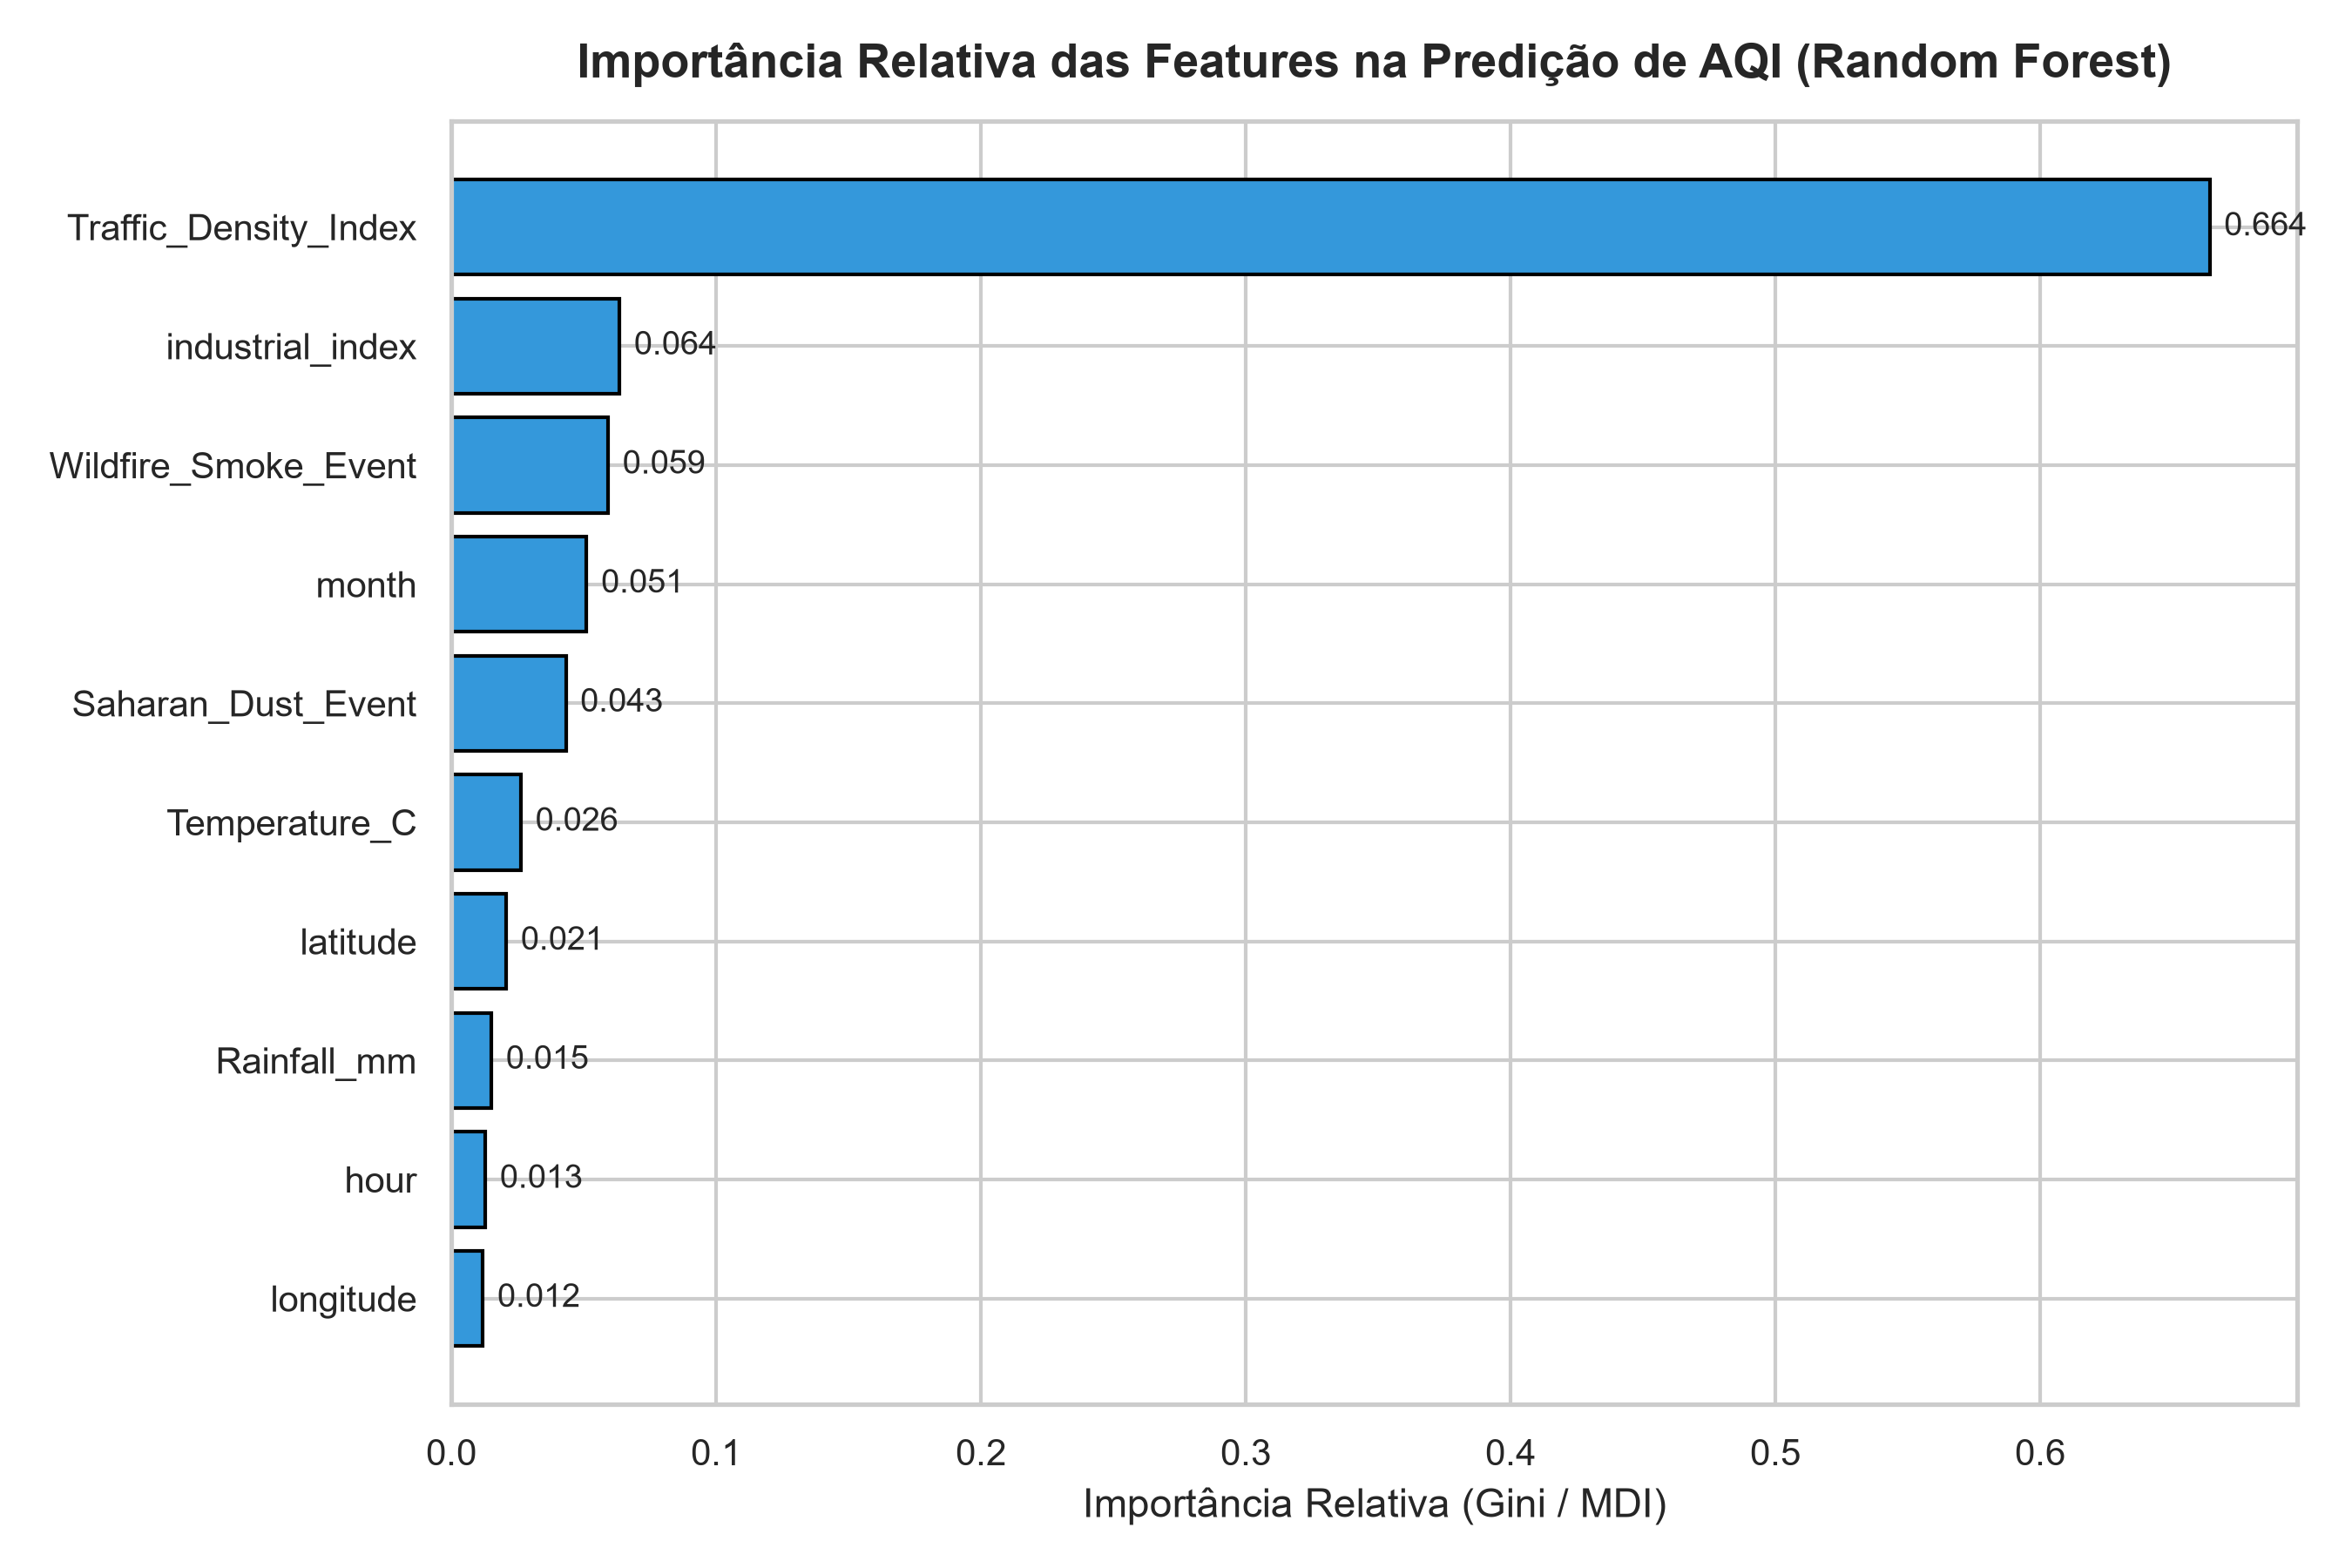

In [4]:
# Separação X e y
X = reg_df.drop(columns=["AQI"])
y = reg_df["AQI"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo baseline rápido com 100 estimadores em subconjunto representativo
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train.iloc[:50000], y_train.iloc[:50000])

y_pred = rf.predict(X_test.iloc[:10000])
r2 = r2_score(y_test.iloc[:10000], y_pred)
mae = mean_absolute_error(y_test.iloc[:10000], y_pred)

print(f"Desempenho Baseline Random Forest (amostra de teste): R² = {r2:.4f}, MAE = {mae:.2f}")

# Gráfico de Importância de Features
fig_imp_path = visualization.plot_feature_importance(
    X.columns.tolist(),
    rf.feature_importances_,
    title="Importância Relativa das Features na Predição de AQI (Random Forest)",
    save_name="regression_feature_importance.png",
    top_n=10,
)
print(f"Gráfico salvo em: {fig_imp_path}")
from IPython.display import Image
Image(filename=str(fig_imp_path))

### 4. Percepções e Recomendações para Modelagem
1. **Principais Features Recomendadas:**
   - `Traffic_Density_Index`: Forte correlação positiva e alta importância no baseline, representando a principal fonte antropogênica de emissão diária.
   - `Wildfire_Smoke_Event` e `Saharan_Dust_Event`: Variáveis binárias que explicam desvios extremos e picos de poluição catastrófica.
   - `industrial_index` e `population`: Capturam o nível basal de poluição estrutural de cada centro urbano.
   - `Wind_Speed_ms` e `Temperature_C`: Governam a dispersão atmosférica e inversões térmicas.

2. **Possíveis Desafios:**
   - **Não-Linearidade e Interações:** A dispersão de poluentes depende simultaneamente de temperatura, velocidade e direção do vento, demandando modelos capazes de capturar interações complexas.
   - **Cauda Longa (Assimetria):** Eventos raros de incêndios geram valores de AQI acima de 400. Modelos de regressão linear simples tendem a subestimar esses picos severos se treinados apenas com perda quadrática comum (MSE).

3. **Sugestões de Algoritmos:**
   - **XGBoost / LightGBM / CatBoost:** Modelos baseados em árvores com gradient boosting são a recomendação primária. Lidam perfeitamente com interações não-lineares, diferentes escalas e são robustos a outliers.
   - **Regressão Ridge / Lasso:** Como modelo linear regularizado para estabelecer uma linha de base interpretável.
   - **Redes Neurais (MLP) ou SVR com kernel RBF:** Adequados quando o conjunto é normalizado e deseja-se aproximação contínua de superfícies não-lineares.